# FLEXtopo Calibration and Validation


In [16]:
# General python

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime
from Weigfun import Weigfun
from plateau import plateau_func
import warnings
warnings.filterwarnings('ignore')
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rich import print
import shutil
import xarray as xr

## Landscape parameters

Each landscape (plateau, hillslope, wetland) has own parameters that need to be calibrated

### Parameter overview
| Unit | Par[0] | Par[1] | Par[2] | Par[3] | Par[4] | Par[5] |
|------|--------|--------|--------|--------|--------|--------|
| Plateau | Imax | Ce | Sumax | beta | Pmax | Kf |
| Hillslope | Imax | Ce | Sumax | beta | D | Kf |
| Wetland | Imax | Ce | Sumax | beta | Cmax | Kf |

Catchment-level: `ParCatchment = [Ks, T_lag]`

### Hillslope

In [64]:
def hillslope_func(timestep, Par, forcing, Fluxes, States):
	# HBVpareto Calculates values of 3 objective functions for HBV model

	I_max = Par[0]
	Ce = Par[1]
	Su_max = Par[2]
	beta = Par[3]
	D = Par[4]
	Kf = Par[5]
	Qo = forcing['Qo']
	Prec = forcing['Prec']
	Etp = forcing['Etp']

	t_max = len(Prec)
	Si = States[:, 0]
	Su = States[:, 1]
	Sf = States[:, 2]

	Ei_dt = Fluxes[:, 0]
	Ea_dt = Fluxes[:, 1]
	Qf_dt = Fluxes[:, 2]
	Qus_dt = Fluxes[:, 3]

	dt = 1
	t = timestep

	P_dt = Prec[t] * dt
	Ep_dt = Etp[t] * dt

	# Interception Reservoir
	if P_dt > 0:
		Si[t] = Si[t] + P_dt
		Pe_dt = max(0, Si[t] - I_max)
		Si[t] = Si[t] - Pe_dt
		Ei_dt[t] = 0
	else:
		# Evaporation only when there is no rainfall
		Pe_dt = 0
		Ei_dt[t] = min(Ep_dt, Si[t])
		Si[t] = Si[t] - Ei_dt[t]

	if t < t_max - 1:
		Si[t + 1] = Si[t]

	# Unsaturated Reservoir
	if Pe_dt > 0:
		rho = (Su[t] / Su_max) ** beta
		Su[t] = Su[t] + (1 - rho) * Pe_dt
		Quf_dt = rho * Pe_dt
	else:
		Quf_dt = 0

	# Transpiration
	Ep_dt = max(0, Ep_dt - Ei_dt[t])
	Ea_dt[t] = Ep_dt * (Su[t] / (Su_max * Ce))
	Ea_dt[t] = min(Ea_dt[t], Su[t])
	Su[t] = Su[t] - Ea_dt[t]
	if t < t_max - 1:
		Su[t + 1] = Su[t]


	# Preferential Percolation
	Qus_dt[t] = D * Quf_dt


	# Fast Reservoir
	Sf[t] = Sf[t] + (1 - D) * Quf_dt
	Qf_dt[t] = dt * Kf * Sf[t]
	Sf[t] = Sf[t] - min(Qf_dt[t], Sf[t])
	if t < t_max - 1:
		Sf[t + 1] = Sf[t]

	# Save output
	States[:, 0] = Si
	States[:, 1] = Su
	States[:, 2] = Sf

	Fluxes[:, 0] = Ei_dt
	Fluxes[:, 1] = Ea_dt
	Fluxes[:, 2] = Qf_dt
	Fluxes[:, 3] = Qus_dt

	return (Fluxes, States)

### Wetlands

In [65]:
def wetland_func(timestep, Par, forcing, Fluxes, States, Ss, landscape_per):
	# HBVpareto Calculates values of 3 objective functions for HBV model

	I_max = Par[0]
	Ce = Par[1]
	Su_max = Par[2]
	beta = Par[3]
	C_max = Par[4]
	Kf = Par[5]

	Qo = forcing['Qo']
	Prec = forcing['Prec']
	Etp = forcing['Etp']


	t_max = len(Prec)
	Si = States[:,0]
	Su = States[:,1]
	Sf = States[:,2]

	Ei_dt = Fluxes[:,0]
	Ea_dt = Fluxes[:,1]
	Qf_dt = Fluxes[:,2]

	dt = 1
	t = timestep

	P_dt = Prec[t] * dt
	Ep_dt = Etp[t] * dt

	# Interception Reservoir
	if P_dt > 0:
		Si[t] = Si[t] + P_dt
		Pe_dt = max(0, Si[t]-I_max)
		Si[t] = Si[t] - Pe_dt
		Ei_dt[t] = 0
	else:
	# Evaporation only when there is no rainfall
		Pe_dt = 0
		Ei_dt[t] = min(Ep_dt, Si[t])
		Si[t] = Si[t] - Ei_dt[t]

	if t < t_max - 1:
		Si[t+1] = Si[t]


	# Unsaturated Reservoir
	if Pe_dt > 0:
		rho = (Su[t]/Su_max) ** beta
		Su[t] = Su[t] + (1-rho) * Pe_dt
		Quf_dt = rho * Pe_dt
	else:
		Quf_dt = 0


	# Transpiration
	Ep_dt = max(0, Ep_dt-Ei_dt[t])
	Ea_dt[t] = Ep_dt * (Su[t]/(Su_max*Ce))
	Ea_dt[t] = min(Ea_dt[t], Su[t])
	Su[t] = Su[t] - Ea_dt[t]


	# Capillary rise
	Qr_dt = (1-Su[t]/Su_max) * C_max * dt
	Qr_dt = min(Qr_dt, Ss[t] /landscape_per) #check if the groundwater has enough water (note: you need to use the landscape percentage!!!)

	if ((Su[t] + Qr_dt) > Su_max):
		Qr_dt = Su_max - Su[t]


	Su[t] = Su[t] + Qr_dt
	Ss[t] = Ss[t] - Qr_dt * landscape_per

	if t < t_max - 1:
		Su[t+1] = Su[t]

	# Fast Reservoir
	Sf[t] = Sf[t] + Quf_dt
	Qf_dt[t] = dt * Kf * Sf[t]
	Sf[t] = Sf[t]- min(Qf_dt[t], Sf[t])
	if t < t_max-1:
		Sf[t+1] = Sf[t]


	# Save output
	States[:,0] = Si
	States[:,1] = Su
	States[:,2] = Sf

	Fluxes[:,0] = Ei_dt
	Fluxes[:,1] = Ea_dt
	Fluxes[:,2] = Qf_dt

	return(Fluxes, States, Ss)

### Plateau

In [66]:
def plateau_func(timestep, Par, forcing, Fluxes, States):
 
    I_max  = Par[0]
    Ce     = Par[1]
    Su_max = Par[2]
    beta   = Par[3]
    P_max  = Par[4]   # max percolation to slow reservoir
    Kf     = Par[5]
 
    Prec = forcing['Prec']
    Etp  = forcing['Etp']
 
    t_max = len(Prec)
    Si    = States[:, 0]
    Su    = States[:, 1]
    Sf    = States[:, 2]
 
    Ei_dt  = Fluxes[:, 0]
    Ea_dt  = Fluxes[:, 1]
    Qf_dt  = Fluxes[:, 2]
    Qus_dt = Fluxes[:, 3]
 
    dt    = 1
    t     = timestep
    P_dt  = Prec[t] * dt
    Ep_dt = Etp[t] * dt
 
    #Interception reservoir
    # Throughfall: precip that exceeds the available interception capacity
    Pe_dt    = max(0, P_dt - max(0, I_max - Si[t]))
    Ei_dt[t] = min(Ep_dt, Si[t] + P_dt - Pe_dt)
 
    if t < t_max - 1:
        Si_new = Si[t] + dt * (P_dt - Pe_dt - Ei_dt[t])
        # FIX: if Si would exceed I_max, route the overflow as additional throughfall
        if Si_new > I_max:
            Pe_dt  += Si_new - I_max
            Si[t+1] = I_max
        else:
            Si[t+1] = max(0, Si_new)
 
    Ep_remain = max(0, Ep_dt - Ei_dt[t])
 
    #Unsaturated reservoir
    Cr    = (Su[t] / Su_max) ** beta
    Pu_dt = (1 - Cr) * Pe_dt   # infiltration into Su
    Qu_dt = Cr * Pe_dt          # direct runoff to fast reservoir
 
    # Transpiration
    Ea_dt[t] = Ce * (Su[t] / Su_max) * Ep_remain
 
    if t < t_max - 1:
        Su_new    = Su[t] + dt * (Pu_dt - Ea_dt[t])
        # Percolation to slow reservoir capped at P_max and available storage
        Qus_dt[t] = min(P_max, max(0, Su_new))
        Su_new   -= Qus_dt[t]
        # FIX: if Su would go negative, route the deficit as additional fast runoff
        if Su_new < 0:
            Qu_dt  += abs(Su_new)
            Su[t+1] = 0
        else:
            Su[t+1] = Su_new
    else:
        Qus_dt[t] = min(P_max, max(0, Su[t]))
 
    #Fast reservoir
    # FIX: compute outflow from Sf[t] (not Sf[t+1]) to avoid forward-time error
    Qf_dt[t] = Kf * Sf[t]
    if t < t_max - 1:
        Sf_new = Sf[t] + dt * Qu_dt - dt * Qf_dt[t]
        # FIX: if Sf would go negative, reduce outflow to what is available
        if Sf_new < 0:
            Qf_dt[t] = Sf[t] + dt * Qu_dt
            Sf[t+1]  = 0
        else:
            Sf[t+1] = Sf_new
 
    States[:, 0] = Si;  States[:, 1] = Su;  States[:, 2] = Sf
    Fluxes[:, 0] = Ei_dt;  Fluxes[:, 1] = Ea_dt
    Fluxes[:, 2] = Qf_dt;  Fluxes[:, 3] = Qus_dt
 
    return Fluxes, States

### Flextopo model 

In [67]:
def FLEXtopo(ParPlateau, ParHillslope, ParWetland, ParCatchment, forcing, landscapes):

	# Parameters and constants
	T_lag = ParCatchment[1]
	Ks = ParCatchment[0]
	dt = 1
	t_max = len(forcing['Qo'])

	# Initialize states
	States_plateau = np.zeros((t_max,3))
	States_hillslope = np.zeros((t_max,3))
	States_wetland = np.zeros((t_max,3))
	Ss = np.zeros((t_max,1))

	# Initialize fluxes
	Fluxes_plateau = np.zeros((t_max,4))
	Fluxes_hillslope = np.zeros((t_max,4))
	Fluxes_wetland = np.zeros((t_max,3))
	Qs_dt = np.zeros(t_max)
	Q_tot_dt = np.zeros(t_max)

	# Loop over time
	for t in range(0,t_max):

		# Plateau
		Fluxes_plateau, States_plateau = plateau_func(t, ParPlateau, forcing, Fluxes_plateau, States_plateau)
		# Hillslope
		Fluxes_hillslope, States_hillslope = hillslope_func(t, ParHillslope, forcing, Fluxes_hillslope, States_hillslope)

		# Wetland
		Fluxes_wetland, States_wetland, Ss = wetland_func(t, ParWetland, forcing, Fluxes_wetland, States_wetland, Ss, landscapes[2])

		# Slow Reservoir
		'''UPDATE'''
		Ss[t] = Ss[t] + Fluxes_plateau[t, 3] * landscapes[0] + Fluxes_hillslope[t, 3] * landscapes[1]
		Qs_dt = dt * Ks * Ss[t]
		Ss[t] = Ss[t] - min(Qs_dt,Ss[t])
		if t < t_max - 1:
			Ss[t+1] = Ss[t]

		'''UPDATE'''
		Q_tot_dt[t] = Qs_dt + Fluxes_plateau[t,2] * landscapes[0] + Fluxes_hillslope[t,2] * landscapes[1] + Fluxes_wetland[t,2] * landscapes[2]

	# Offset Q
	weigths = Weigfun(T_lag)

	Qm = np.convolve(Q_tot_dt, weigths)
	Qm = Qm[0:t_max]

	return(Qm)

## Landscapes

In QGIS we made HAND (Height Above Nearest Drainage): separates wetlands (low-lying) from upland units and the slope which separates plateaus from steeper hillslopes.

In [21]:
DEM = np.genfromtxt('DEM_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)
slope = np.genfromtxt('slope_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)
hand = np.genfromtxt('HAND_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)
basin = np.genfromtxt('basin_killawarra.asc',  dtype=float, autostrip=True, skip_header=6)

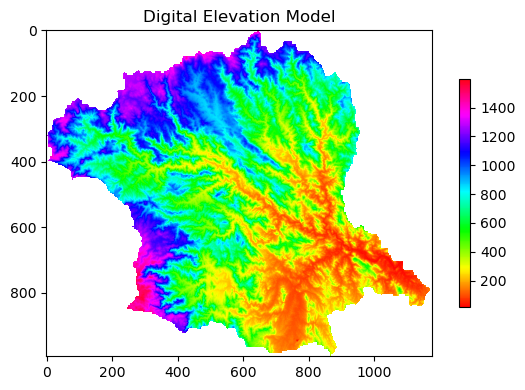

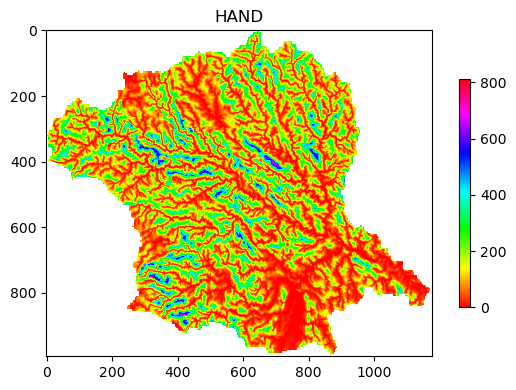

In [22]:
#plot DEM
fig, ax = plt.subplots(figsize=(6,4))
ax.set_title('Digital Elevation Model')
DEM[DEM==-9999] = np.nan
im = ax.imshow(DEM, cmap='hsv')
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()

# plot HAND
fig, ax = plt.subplots(figsize=(6,4))
ax.set_title('HAND')
hand[hand==-9999] = np.nan
im = ax.imshow(hand, cmap='hsv')
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()

## Classification
This is the classification we made:
| Class | Condition |
|-------|-----------|
| Wetland | HAND ≤ 5 m AND slope ≤ 9% |
| Plateau | HAND > 5 m AND slope ≤ 9% |
| Hillslope | slope > 9% |


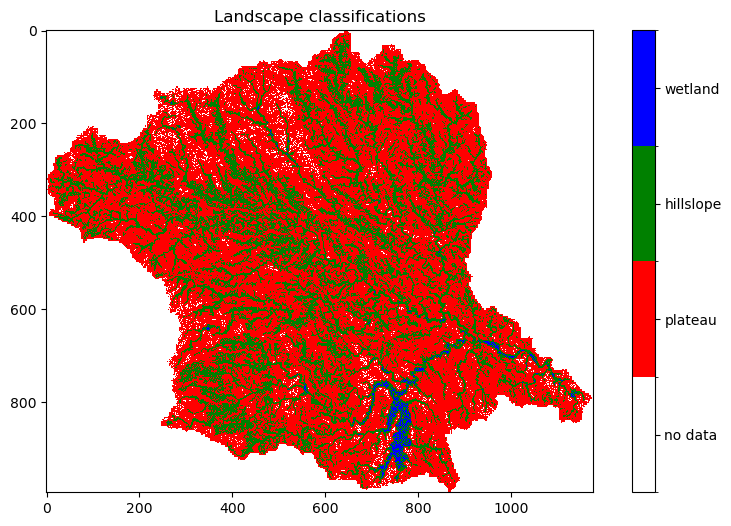

Hillslope percentage: 0.6040544567109684

Wetland percentage: 0.08657050074945284

Plateau percentage: 0.3092918540298783

In [23]:
'''UPDATE'''
# Make landscape classification
hillslope = np.array(slope) > 9
plateau = (np.array(hand) > 5) & (np.array(slope) <= 9)
wetland = (np.array(hand) <= 5) & (np.array(slope) <= 9)
basin = np.array(basin) > 0

'''UPDATE'''
hillslope_per = float(np.sum(hillslope))/float(np.sum(basin))
wetland_per = float(np.sum(wetland))/float(np.sum(basin))
plateau_per = float(np.sum(plateau))/float(np.sum(basin))

landscapes = np.zeros(DEM.shape)
landscapes[plateau] = 1
landscapes[hillslope] = 2
landscapes[wetland] = 3

# Plot landscapes
cmap = mpl.colors.ListedColormap(['white', 'red', 'green', 'blue'])
bounds = [0,1,2,3,4]
labels = ['no data', 'plateau', 'hillslope', 'wetland']
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, )

fig, ax = plt.subplots(figsize=(10,6))
ax.set_title('Landscape classifications')
im = ax.imshow(landscapes, cmap=cmap, norm=norm,)
# Create color bar
cbar = plt.colorbar(im, ticks=[0.5, 1.5, 2.5, 3.5])
cbar.set_ticklabels(labels)
plt.show()
landscape_per = np.array([plateau_per, hillslope_per, wetland_per])

print("Hillslope percentage:", hillslope_per)
print("Wetland percentage:", wetland_per)
print("Plateau percentage:", plateau_per)


## Loading forcing data 



In [39]:
# path = Path.cwd()
# forcing_path = path / "Forcing"

# own_region = "manning"
# shapeFile = forcing_path / f"{own_region}.shp"
# saveLocation = forcing_path / f"{own_region}Forcing"

In [194]:
experiment_start_time  = "2014-01-01T00:00:00Z"
experiment_end_time    = "2024-12-31T00:00:00Z"

calibration_start_time = "2014-01-01T00:00:00Z"
calibration_end_time   = "2022-12-31T00:00:00Z"

validation_start_time  = "2023-01-01T00:00:00Z"
validation_end_time    = "2024-12-31T00:00:00Z"

Test parameters

Plateau   : [ 3.75   0.8   90.     1.4    1.1    0.225]

Hillslope : [3.75e+00 8.00e-01 3.00e+02 1.40e+00 3.25e-01 2.75e-01]

Wetland   : [  4.      0.8   105.      1.4     0.425   0.165]

Catchment : [0.0255 3.    ]

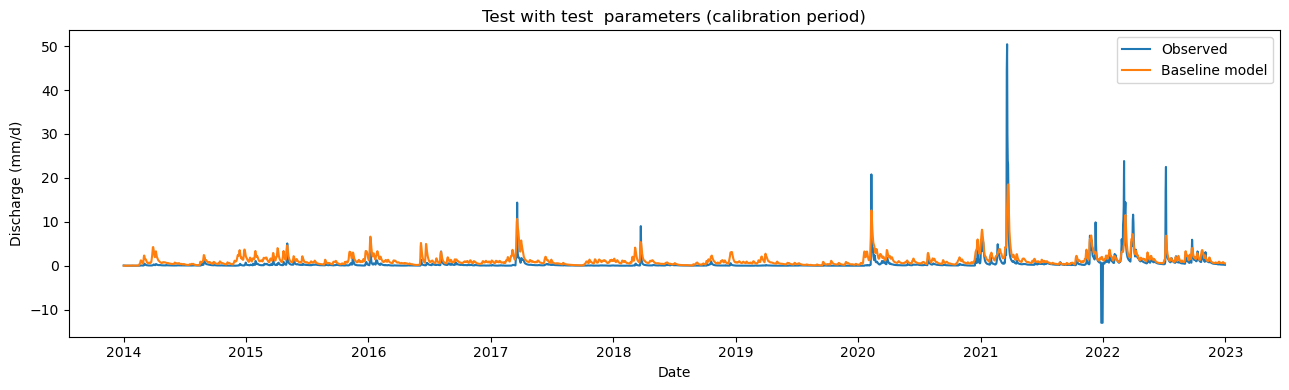

In [195]:

#discharge
df = pd.read_csv(
    './Data/5202080_Q_Day.Cmd.txt',
    delimiter=';',
    skiprows=36,
    header=0,
    encoding='cp1252'
)

df.columns = ["Date", "Time", "Discharge"]
df["Discharge"] = pd.to_numeric(df["Discharge"], errors="coerce")
df = df.dropna(subset=["Discharge"])
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
df = df.set_index("Date")
df = df.drop(columns=["Time"])
df = df.sort_index()

#precip
precip = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
precip["Date"] = pd.to_datetime(precip["system:index"], format="%Y%m%d")
precip = precip.set_index("Date")[["total_precipitation_sum"]]
precip = precip.rename(columns={"total_precipitation_sum": "pr"})
precip["pr"] = precip["pr"] * 1000   # m/day → mm/day

#evap
evap = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
evap["Date"] = pd.to_datetime(evap["system:index"], format="%Y%m%d")
evap = evap.set_index("Date")[["total_evaporation_sum"]]
evap = evap.rename(columns={"total_evaporation_sum": "evspsblpot"})
evap["evspsblpot"] = evap["evspsblpot"].abs() * 1000   # m/day → mm/day

labels_plateau   = ['Imax', 'Ce', 'Sumax', 'beta', 'Pmax', 'Kf']
labels_hillslope = ['Imax', 'Ce', 'Sumax', 'beta', 'D',    'Kf']
labels_wetland   = ['Imax', 'Ce', 'Sumax', 'beta', 'Cmax', 'Kf']
labels_catchment = ['Ks', 'T_lag']

# Parameter bounds
p_min_plateau   = np.array([2.0, 0.4,  30.0, 0.8, 0.2, 0.05])
p_max_plateau   = np.array([5.5, 1.2, 150.0, 2.0, 2.0, 0.40])

p_min_hillslope = np.array([2.0, 0.4, 100.0, 0.8, 0.05, 0.05])
p_max_hillslope = np.array([5.5, 1.2, 500.0, 2.0, 0.60, 0.50])

p_min_wetland   = np.array([2.0, 0.4,  30.0, 0.8, 0.05, 0.03])
p_max_wetland   = np.array([6.0, 1.2, 180.0, 2.0, 0.80, 0.30])

p_min_catch     = np.array([0.001, 1.0])
p_max_catch     = np.array([0.05,  5.0])
par_plateau   = (p_min_plateau   + p_max_plateau) / 2
par_hillslope = (p_min_hillslope + p_max_hillslope) / 2
par_wetland   = (p_min_wetland   + p_max_wetland) / 2
par_catch     = (p_min_catch     + p_max_catch) / 2

Qm_baseline = FLEXtopo(
    par_plateau,
    par_hillslope,
    par_wetland,
    par_catch,
    df_cal,
    landscape_per
)

Qo_baseline = df_cal["Qo"].values

print("Test parameters")
print("Plateau   :", par_plateau)
print("Hillslope :", par_hillslope)
print("Wetland   :", par_wetland)
print("Catchment :", par_catch)


# Plot
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_cal.index, df_cal["Qo"], label="Observed")
ax.plot(df_cal.index, Qm_baseline, label="Baseline model")
ax.set_title("Test with test  parameters (calibration period)")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge (mm/d)")
ax.legend()
plt.tight_layout()
plt.show()




# #forcing
forcing_df = precip.join(evap, how="inner")
forcing_df = forcing_df.rename(columns={
    "pr": "Prec",
    "evspsblpot": "Etp"
})
forcing_df["Qo"] = df["Discharge"]
forcing_df.index = forcing_df.index.normalize()
forcing_df = forcing_df.sort_index()

df_cal = forcing_df.loc["2014-01-01":"2022-12-31"]
df_val = forcing_df.loc["2023-01-01":"2024-12-31"]



In [199]:
ds = xr.Dataset(
    data_vars={
        "pr": ("time", forcing_df["Prec"].values),
        "evspsblpot": ("time", forcing_df["Etp"].values),
    },
    coords={"time": forcing_df.index.values},
    attrs={"title": "Manning HBV forcing using custom precipitation and evaporation"}
)

ds["pr"].attrs["units"] = "mm/day"
ds["evspsblpot"].attrs["units"] = "mm/day"

ds.to_netcdf("Forcing/manning_hbv_forcing_custom.nc")


In [200]:
from ewatercycle_wrapper_HBV import HBV

forcing = {
    "directory": "Forcing",
    "start_time": forcing_df.index.min().strftime("%Y-%m-%dT00:00:00Z"),
    "end_time": forcing_df.index.max().strftime("%Y-%m-%dT00:00:00Z"),
    "pr": "manning_hbv_forcing_custom.nc",
    "evspsblpot": "manning_hbv_forcing_custom.nc",
}

model = HBV(forcing=forcing)


In [201]:
xr.open_dataset("Forcing/manning_hbv_forcing_custom.nc")


<xarray.Dataset> Size: 394kB
Dimensions:     (time: 16436)
Coordinates:
  * time        (time) datetime64[ns] 131kB 1981-01-01 1981-01-02 ... 2025-12-31
Data variables:
    pr          (time) float64 131kB ...
    evspsblpot  (time) float64 131kB ...
Attributes:
    title:    Manning HBV forcing using custom precipitation and evaporation

In [202]:
forcing_df.index.min(), forcing_df.index.max()


(Timestamp('1981-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [205]:
# --- Warm-up period ---
df_warmup = forcing_df.loc["2014-01-01":"2016-12-31"]

# --- Calibration period ---
df_cal = forcing_df.loc["2014-01-01":"2022-12-31"]

# --- Combined warm-up + calibration ---
df_run = forcing_df.loc["2014-01-01":"2022-12-31"]

# --- Run FLEXtopo (must include Qo!) ---
Qm_full = run_flextopo_flat(param_vector, df_run[["Prec", "Etp", "Qo"]], landscape_per)

# --- Extract calibration simulation (drop warm-up) ---
Qm_cal = Qm_full[len(df_warmup):]


In [206]:

from ewatercycle_wrapper_HBV import HBV



forcing = {
    "directory": "Forcing",
    "start_time": forcing_df.index.min().strftime("%Y-%m-%dT00:00:00Z"),
    "end_time": forcing_df.index.max().strftime("%Y-%m-%dT00:00:00Z"),
    "pr": "manning_hbv_forcing_custom.nc",
    "evspsblpot": "manning_hbv_forcing_custom.nc",
}

model = HBV(forcing=forcing)


Test parameters

Plateau   : [ 3.75   0.8   90.     1.4    1.1    0.225]

Hillslope : [3.75e+00 8.00e-01 3.00e+02 1.40e+00 3.25e-01 2.75e-01]

Wetland   : [  4.      0.8   105.      1.4     0.425   0.165]

Catchment : [0.0255 3.    ]

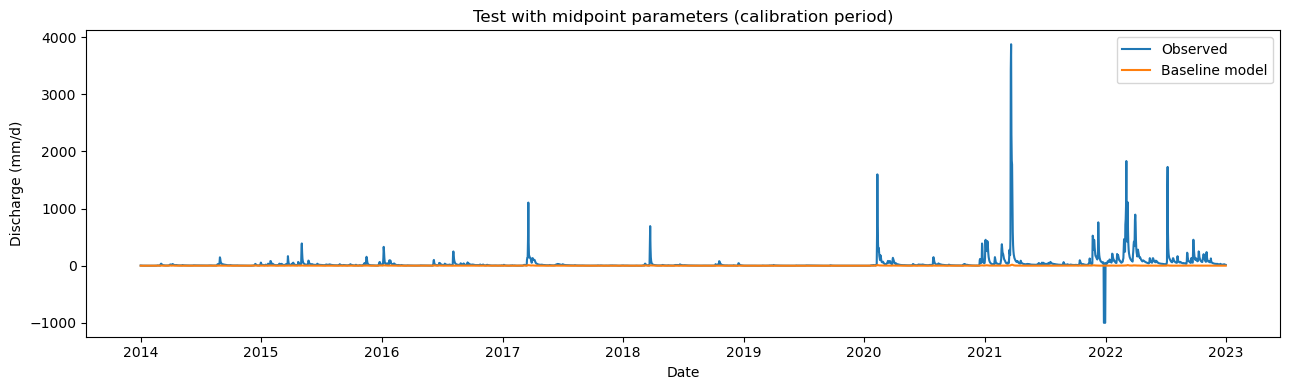

In [213]:
# Parameter bounds
p_min_plateau   = np.array([2.0, 0.4,  30.0, 0.8, 0.2, 0.05])
p_max_plateau   = np.array([5.5, 1.2, 150.0, 2.0, 2.0, 0.40])

p_min_hillslope = np.array([2.0, 0.4, 100.0, 0.8, 0.05, 0.05])
p_max_hillslope = np.array([5.5, 1.2, 500.0, 2.0, 0.60, 0.50])

p_min_wetland   = np.array([2.0, 0.4,  30.0, 0.8, 0.05, 0.03])
p_max_wetland   = np.array([6.0, 1.2, 180.0, 2.0, 0.80, 0.30])

p_min_catch     = np.array([0.001, 1.0])
p_max_catch     = np.array([0.05,  5.0])

# Midpoints
par_plateau   = (p_min_plateau   + p_max_plateau) / 2
par_hillslope = (p_min_hillslope + p_max_hillslope) / 2
par_wetland   = (p_min_wetland   + p_max_wetland) / 2
par_catch     = (p_min_catch     + p_max_catch) / 2

# FLEXtopo forcing subset
forcing_df_flex = forcing_df[["Prec", "Etp", "Qo"]]

# Baseline run
Qm_baseline = FLEXtopo(
    par_plateau,
    par_hillslope,
    par_wetland,
    par_catch,
    forcing_df_flex.loc[df_cal.index],
    landscape_per
)

Qo_baseline = df_cal["Qo"].values

print("Test parameters")
print("Plateau   :", par_plateau)
print("Hillslope :", par_hillslope)
print("Wetland   :", par_wetland)
print("Catchment :", par_catch)

# Plot
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_cal.index, df_cal["Qo"], label="Observed")
ax.plot(df_cal.index, Qm_baseline, label="Baseline model")
ax.set_title("Test with midpoint parameters (calibration period)")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge (mm/d)")
ax.legend()
plt.tight_layout()
plt.show()


In [214]:
def mae_objective(Qm, Qo): #mean ablolute errorrr, lower better
    Qm = np.asarray(Qm, dtype=float)
    Qo = np.asarray(Qo, dtype=float)
    n = min(len(Qm), len(Qo))
    sim = Qm[:n]
    obs = Qo[:n]
    valid = ~np.isnan(obs) & ~np.isnan(sim)
    sim = sim[valid]
    obs = obs[valid]
    if len(obs) == 0:
        return np.nan
    return np.mean(np.abs(obs - sim))
    
def nse_objective(Qm, Qo):   #Nash-Sutcliffe Efficiency and log-NSE
    Qm = np.asarray(Qm, dtype=float)
    Qo = np.asarray(Qo, dtype=float)

    n = min(len(Qm), len(Qo))
    sim = Qm[:n]
    obs = Qo[:n]

    valid = ~np.isnan(obs) & ~np.isnan(sim)
    sim = sim[valid]
    obs = obs[valid]

    if len(obs) == 0:
        return np.nan, np.nan

    obs_mean = np.mean(obs)
    denom = np.sum((obs - obs_mean) ** 2)

    if denom == 0:
        nse = np.nan
    else:
        nse = 1.0 - np.sum((obs - sim) ** 2) / denom

    eps = 1e-6
    log_obs = np.log(np.maximum(obs, eps))
    log_sim = np.log(np.maximum(sim, eps))

    log_denom = np.sum((log_obs - np.mean(log_obs)) ** 2)
    if log_denom == 0:
        log_nse = np.nan
    else:
        log_nse = 1.0 - np.sum((log_obs - log_sim) ** 2) / log_denom

    return nse, log_nse

## Run Model

We loaded our data above and saved it as forcing. The parameters are defined before for with the HBV model, now we  need to define them for Plateau, Hillslope and Wetland areas. Ks and T_lag are defined for the whole catchment.

In [ ]:
## Calibration for finding parameters
def run_flextopo_flat(param_vector, forcing_df, landscape_per):
    ParPlateau   = np.array(param_vector[0:6])
    ParHillslope = np.array(param_vector[6:12])
    ParWetland   = np.array(param_vector[12:18])
    ParCatchment = np.array(param_vector[18:20])

    return FLEXtopo(
        ParPlateau,
        ParHillslope,
        ParWetland,
        ParCatchment,
        forcing_df,
        landscape_per
    )

p_min_plateau   = np.array([2.0, 0.4,  30.0, 0.8, 0.2, 0.05])
p_max_plateau   = np.array([5.5, 1.2, 150.0, 2.0, 2.0, 0.40])

p_min_hillslope = np.array([2.0, 0.4, 100.0, 0.8, 0.05, 0.05])
p_max_hillslope = np.array([5.5, 1.2, 500.0, 2.0, 0.60, 0.50])

p_min_wetland   = np.array([2.0, 0.4,  30.0, 0.8, 0.05, 0.03])
p_max_wetland   = np.array([6.0, 1.2, 180.0, 2.0, 0.80, 0.30])

p_min_catch     = np.array([0.001, 1.0])
p_max_catch     = np.array([0.05,  5.0])

p_min_flat = np.concatenate([p_min_plateau, p_min_hillslope, p_min_wetland, p_min_catch])
p_max_flat = np.concatenate([p_max_plateau, p_max_hillslope, p_max_wetland, p_max_catch])
Qo_cal = df_cal["Qo"].values
N = 5000
rng = np.random.default_rng(seed=42)

parameter_ensemble = rng.uniform(
    low=p_min_flat,
    high=p_max_flat,
    size=(N, 20)
)

print(f"Sampling {N} parameter sets, each with {parameter_ensemble.shape[1]} parameters")

Qo_cal = df_cal["Qo"].values

best_nse = -np.inf
best_log_nse = np.nan
best_mae = np.nan
best_param_vector = None
best_Qm = None

for i in range(N):
    param_vector = rng.uniform(low=p_min_flat, high=p_max_flat, size=20)

    try:
        # run inclusief warm-up
        Qm_full = run_flextopo_flat(param_vector, df_cal_run, landscape_per)

        # warm-up afknippen zodat model en observaties exact dezelfde periode hebben
        Qm_cal = np.asarray(Qm_full[n_warmup:], dtype=float)

        # extra veiligheidscheck
        n = min(len(Qm_cal), len(Qo_cal))
        Qm_cal = Qm_cal[:n]
        Qo_use = Qo_cal[:n]

        mae = mae_objective(Qm_cal, Qo_use)
        nse, log_nse = nse_objective(Qm_cal, Qo_use)

        if np.isfinite(nse) and nse > best_nse:
            best_nse = nse
            best_log_nse = log_nse
            best_mae = mae
            best_param_vector = param_vector.copy()
            best_Qm = Qm_cal.copy()

    except Exception:
        continue
print("Best run found")
print(f"NSE    : {best_nse:.3f}")
print(f"logNSE : {best_log_nse:.3f}")
print(f"MAE    : {best_mae:.3f}")

ParPlateau_best   = best_param_vector[0:6]
ParHillslope_best = best_param_vector[6:12]
ParWetland_best   = best_param_vector[12:18]
ParCatchment_best = best_param_vector[18:20]



Sampling 5000 parameter sets, each with 20 parameters

In [ ]:
n_plot = min(len(df_cal), len(best_Qm))

plt.figure(figsize=(13, 4))
plt.plot(df_cal.index[:n_plot], df_cal["Qo"].values[:n_plot], label="Observed", color="black", alpha=0.8)
plt.plot(df_cal.index[:n_plot], best_Qm[:n_plot], label=f"Best model (NSE={best_nse:.3f})", alpha=0.8)

plt.title("Best calibration run")
plt.xlabel("Date")
plt.ylabel("Discharge (mm/d)")
plt.legend()
plt.tight_layout()
plt.show()

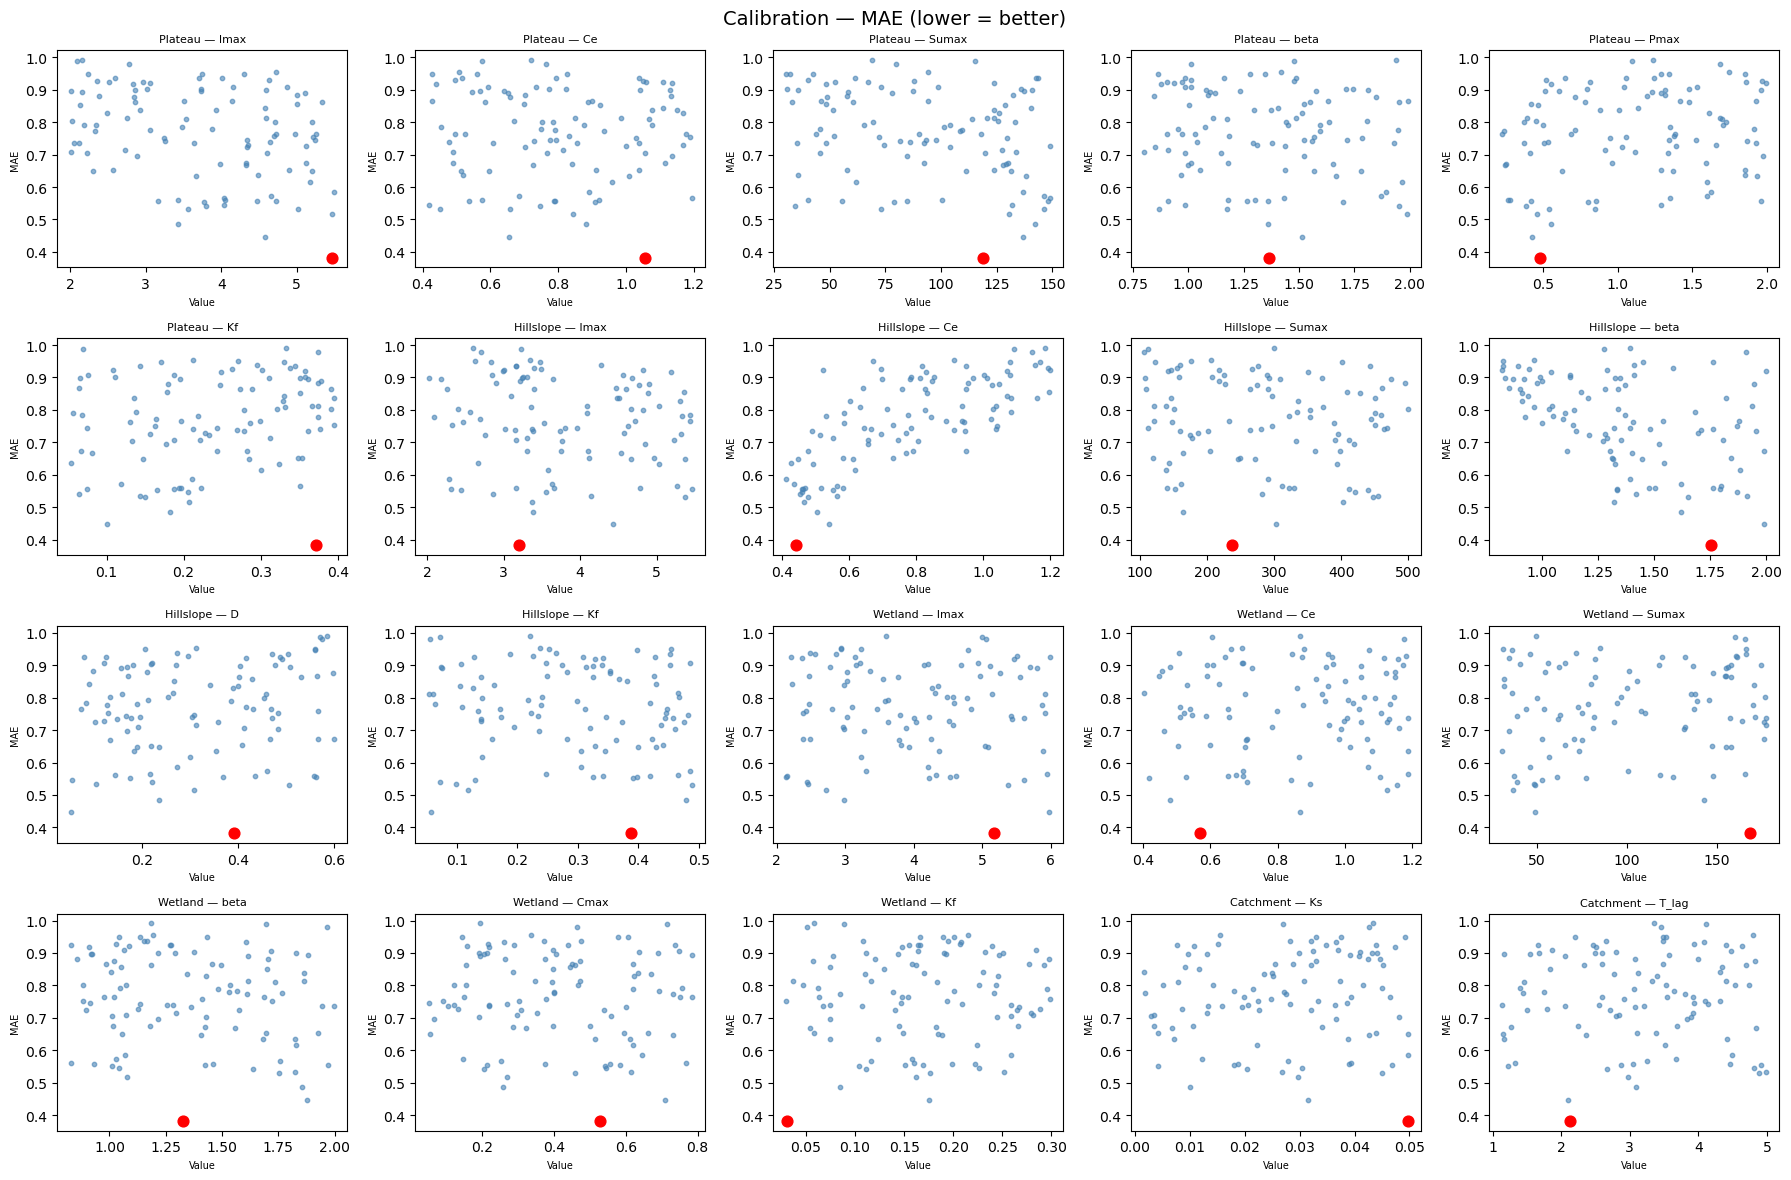

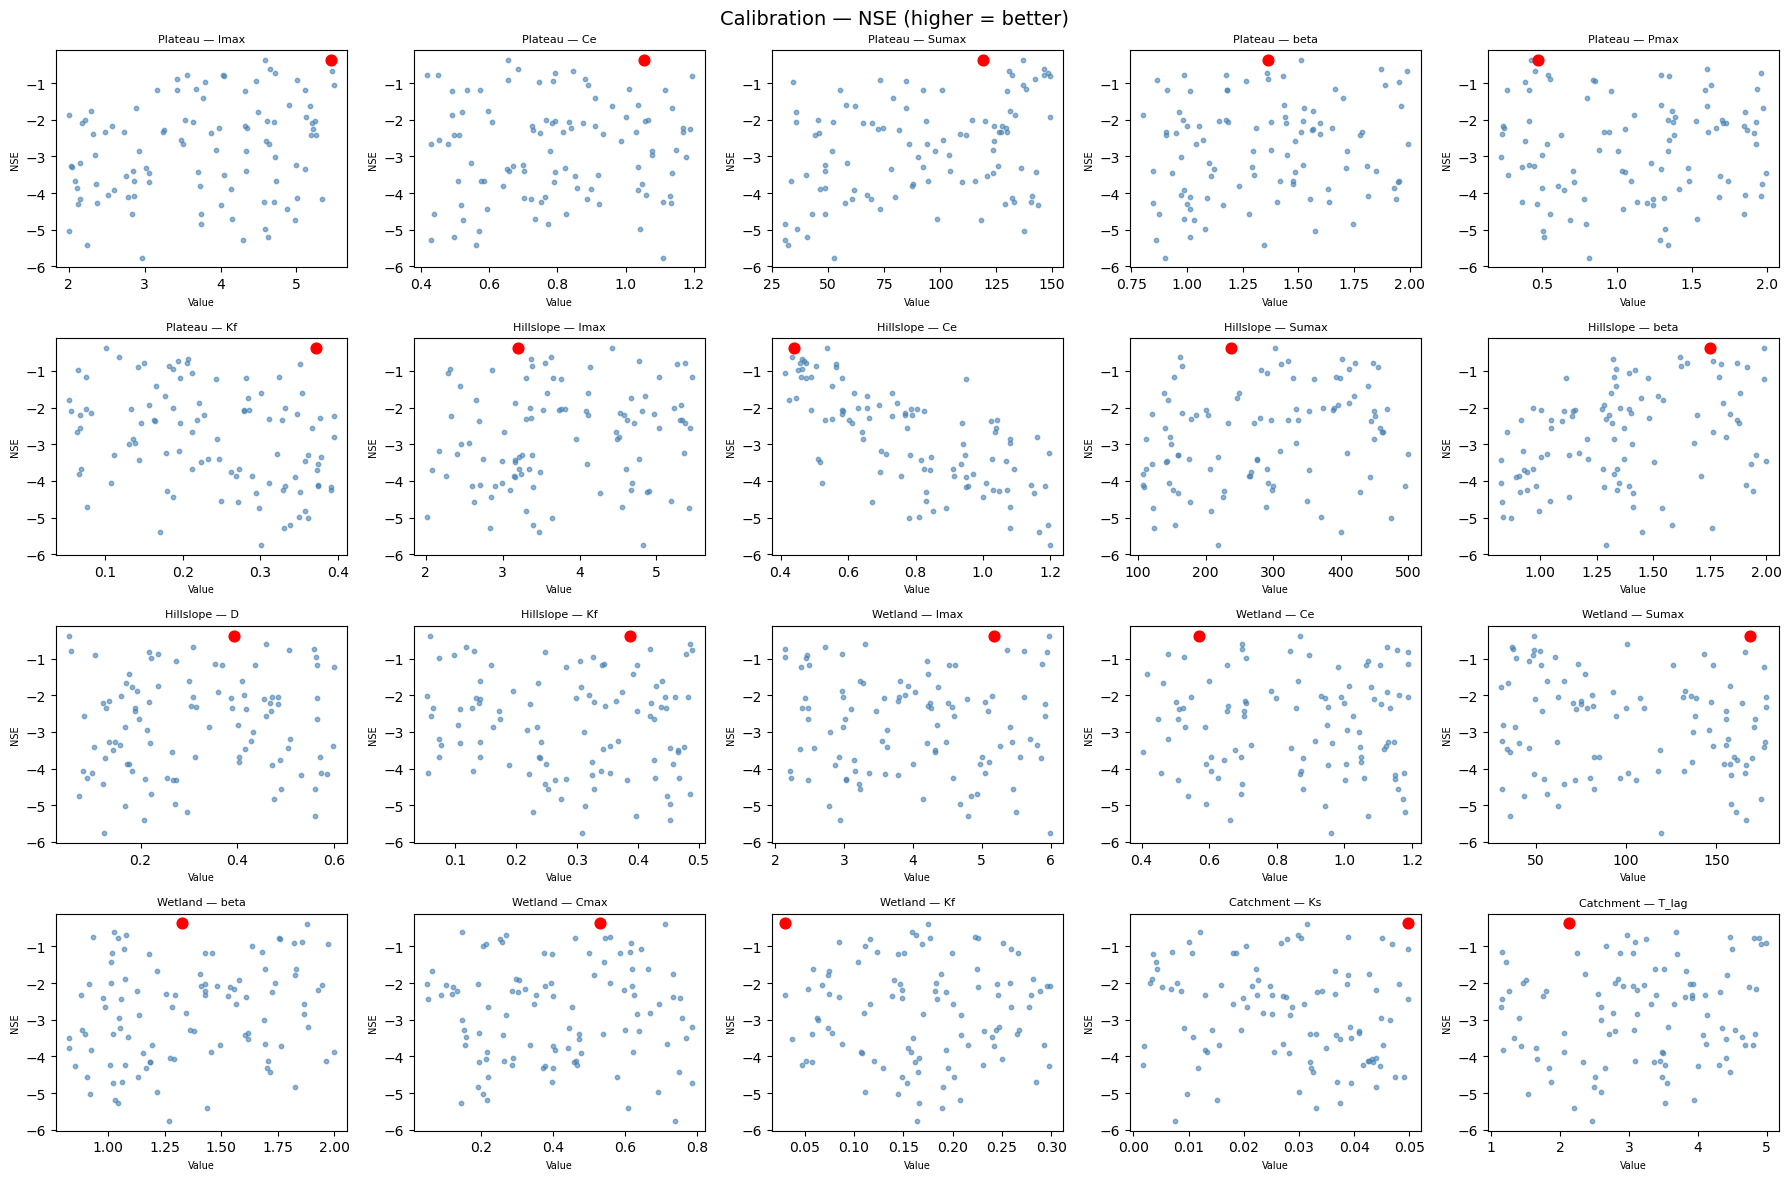

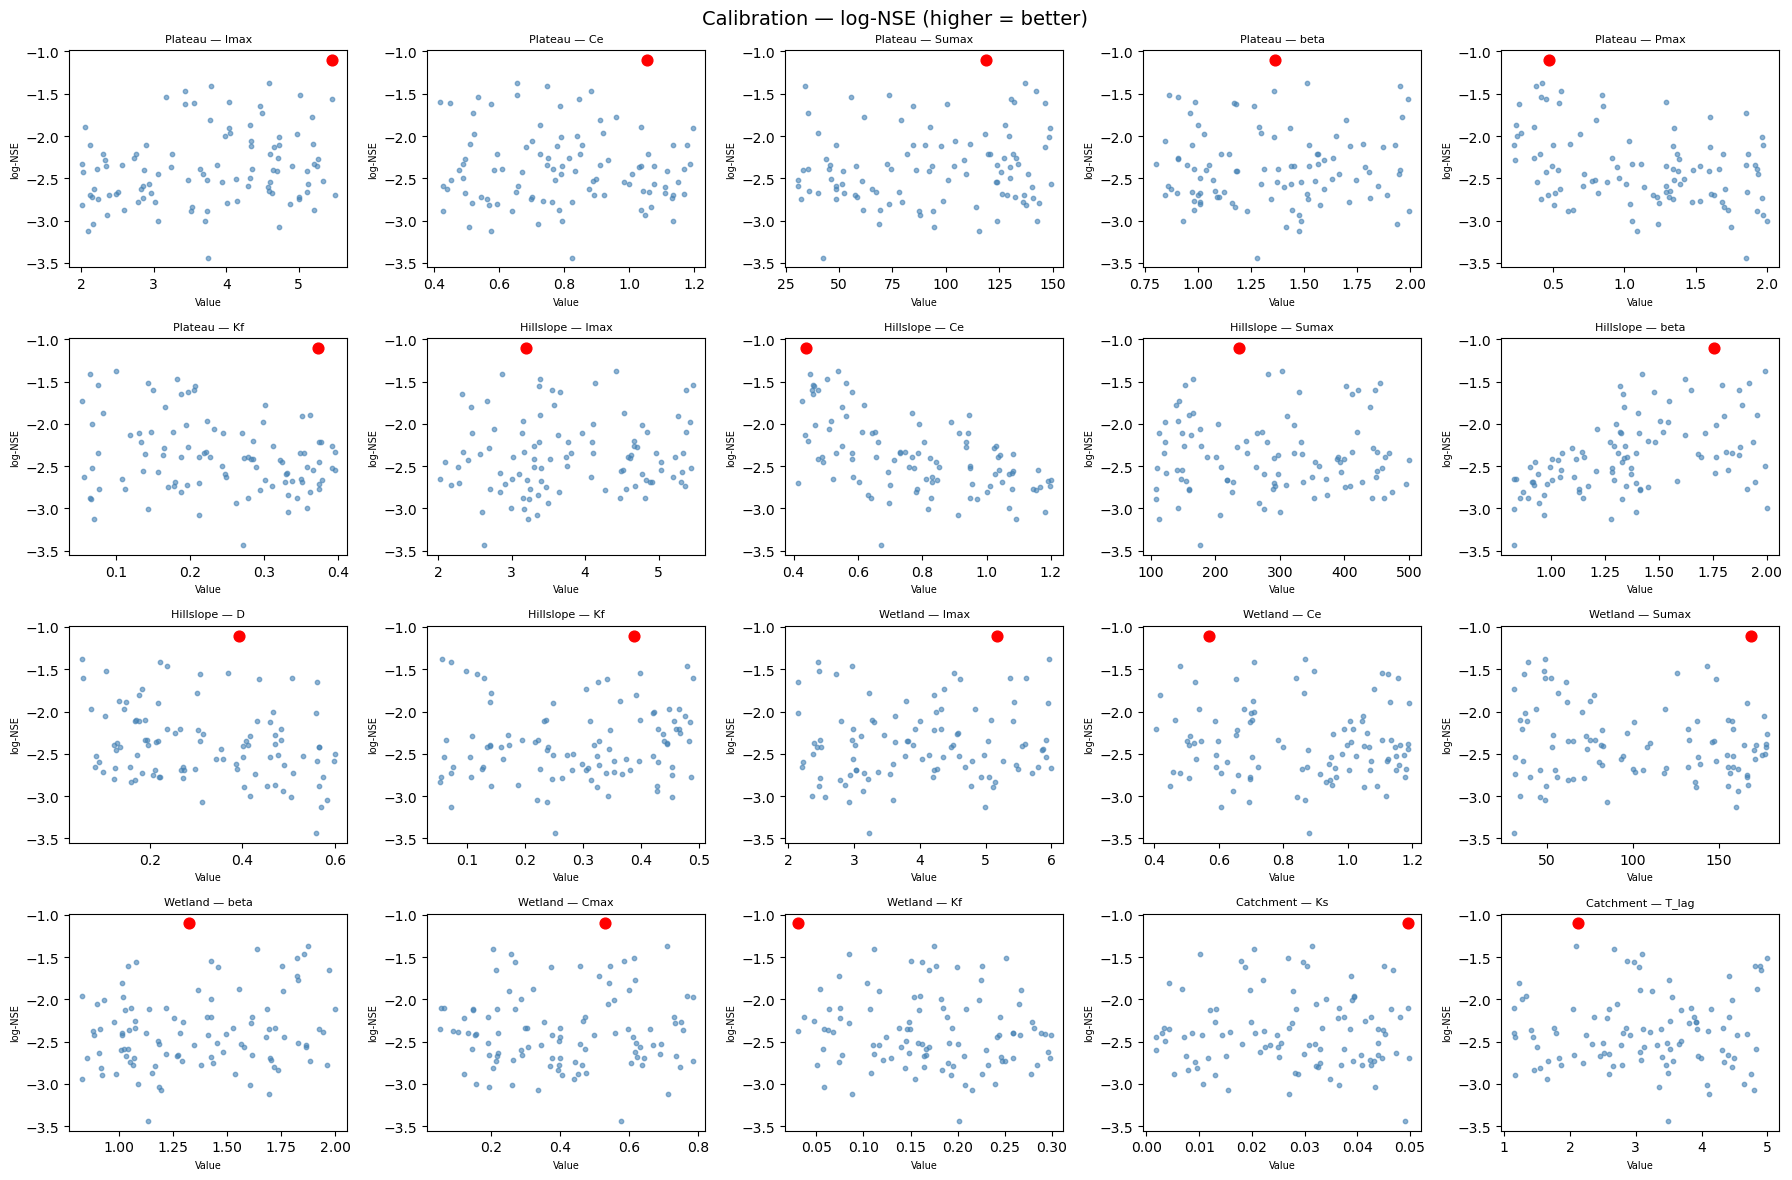

In [95]:
labels_plateau   = ['Imax', 'Ce', 'Sumax', 'beta', 'Pmax', 'Kf']
labels_hillslope = ['Imax', 'Ce', 'Sumax', 'beta', 'D',    'Kf']
labels_wetland   = ['Imax', 'Ce', 'Sumax', 'beta', 'Cmax', 'Kf']
labels_catchment = ['Ks', 'T_lag']

all_labels = (
    [f'Plateau — {l}'   for l in labels_plateau]   +
    [f'Hillslope — {l}' for l in labels_hillslope] +
    [f'Wetland — {l}'   for l in labels_wetland]   +
    [f'Catchment — {l}' for l in labels_catchment]
)

mae_scores     = results_df["MAE"].values
nse_values     = results_df["NSE"].values
log_nse_values = results_df["logNSE"].values

def dotty_plots(scores, title, ylabel, best_fn):
    n = min(len(parameter_ensemble), len(scores))
    params = parameter_ensemble[:n]
    scores = np.asarray(scores[:n], dtype=float)

    n_params = params.shape[1]
    ncols = 5
    nrows = -(-n_params // ncols)

    fig, axs = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
    fig.suptitle(title, fontsize=14)
    axs = axs.flatten()

    valid = np.isfinite(scores)
    valid_idx = np.where(valid)[0]
    best_local = best_fn(scores[valid])
    best_idx = valid_idx[best_local]

    for j in range(n_params):
        axs[j].scatter(params[valid, j], scores[valid], s=10, alpha=0.6, color='steelblue')
        axs[j].scatter(params[best_idx, j], scores[best_idx],
                       s=60, color='red', zorder=5, label='Best')
        axs[j].set_title(all_labels[j], fontsize=8)
        axs[j].set_xlabel('Value', fontsize=7)
        axs[j].set_ylabel(ylabel, fontsize=7)

    for j in range(n_params, len(axs)):
        axs[j].set_visible(False)

    plt.tight_layout()

dotty_plots(mae_scores,       'Calibration — MAE (lower = better)',       'MAE',     np.argmin)
dotty_plots(nse_values,       'Calibration — NSE (higher = better)',      'NSE',     np.argmax)
dotty_plots(log_nse_values,   'Calibration — log-NSE (higher = better)',  'log-NSE', np.argmax)

In [96]:
best_idx_mae    = np.nanargmin(mae_scores)
best_idx_nse    = np.nanargmax(nse_values)
best_idx_lognse = np.nanargmax(log_nse_values)

best_params_mae    = parameter_ensemble[best_idx_mae]
best_params_nse    = parameter_ensemble[best_idx_nse]
best_params_lognse = parameter_ensemble[best_idx_lognse]

def print_params(flat_p, label):
    print(f'\n{label}')
    print(f'  Plateau:    {dict(zip(labels_plateau,   np.round(flat_p[0:6], 4)))}')
    print(f'  Hillslope:  {dict(zip(labels_hillslope, np.round(flat_p[6:12], 4)))}')
    print(f'  Wetland:    {dict(zip(labels_wetland,   np.round(flat_p[12:18], 4)))}')
    print(f'  Catchment:  {dict(zip(labels_catchment, np.round(flat_p[18:20], 4)))}')

print_params(best_params_mae,    f'Best MAE     = {mae_scores[best_idx_mae]:.4f}')
print_params(best_params_nse,    f'Best NSE     = {nse_values[best_idx_nse]:.4f}')
print_params(best_params_lognse, f'Best log-NSE = {log_nse_values[best_idx_lognse]:.4f}')

Best MAE     = 0.3824

Plateau:    {'Imax': 5.4601, 'Ce': 1.0546, 'Sumax': 118.9938, 'beta': 1.3625, 'Pmax': 0.4752, 'Kf': 0.3722}

Hillslope:  {'Imax': 3.1949, 'Ce': 0.4401, 'Sumax': 236.9615, 'beta': 1.7533, 'D': 0.3925, 'Kf': 0.3879}

Wetland:    {'Imax': 5.1745, 'Ce': 0.5696, 'Sumax': 168.5675, 'beta': 1.3256, 'Cmax': 0.5293, 'Kf': 0.0306}

Catchment:  {'Ks': 0.0497, 'T_lag': 2.1236}

...

Best log-NSE = -1.1029

Plateau:    {'Imax': 5.4601, 'Ce': 1.0546, 'Sumax': 118.9938, 'beta': 1.3625, 'Pmax': 0.4752, 'Kf': 0.3722}

Hillslope:  {'Imax': 3.1949, 'Ce': 0.4401, 'Sumax': 236.9615, 'beta': 1.7533, 'D': 0.3925, 'Kf': 0.3879}

Wetland:    {'Imax': 5.1745, 'Ce': 0.5696, 'Sumax': 168.5675, 'beta': 1.3256, 'Cmax': 0.5293, 'Kf': 0.0306}

Catchment:  {'Ks': 0.0497, 'T_lag': 2.1236}

In [97]:
# =========================
# Validation
# =========================
Qo_val = df_val["Qo"].values

results_val = {}

for label, flat_p in [
    ('MAE', best_params_mae),
    ('NSE', best_params_nse),
    ('log-NSE', best_params_lognse)
]:
    Qm_val = run_flextopo_flat(flat_p, df_val, landscape_per)

    mae_v = mae_objective(Qm_val, Qo_val)
    nse_v, lognse_v = nse_objective(Qm_val, Qo_val)

    results_val[label] = {
        'Qm': Qm_val,
        'MAE': mae_v,
        'NSE': nse_v,
        'log-NSE': lognse_v
    }

    print(f'Calibrated on {label:8s} → validation MAE={mae_v:.4f}  NSE={nse_v:.4f}  log-NSE={lognse_v:.4f}')

Calibrated on MAE      → validation MAE=0.4104  NSE=0.5860  log-NSE=0.2192

Calibrated on NSE      → validation MAE=0.4104  NSE=0.5860  log-NSE=0.2192

Calibrated on log-NSE  → validation MAE=0.4104  NSE=0.5860  log-NSE=0.2192

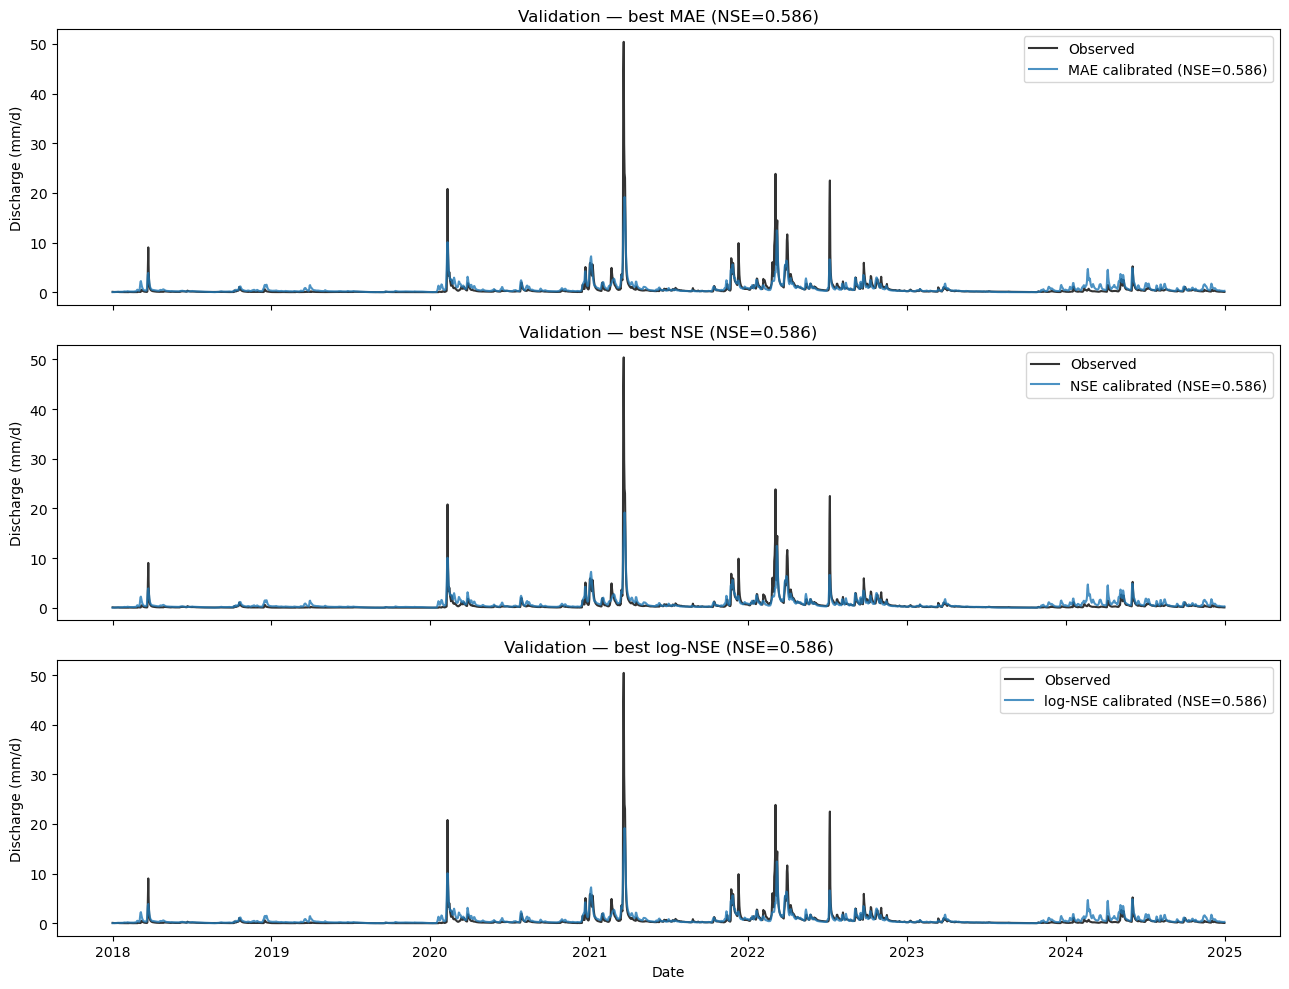

In [101]:
fig, axs = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, (label, out) in zip(axs, results_val.items()):
    n_plot = min(len(df_val), len(out["Qm"]))

    ax.plot(df_val.index[:n_plot],
            df_val["Qo"].values[:n_plot],
            label="Observed",
            color="black",
            alpha=0.8)

    ax.plot(df_val.index[:n_plot],
            out["Qm"][:n_plot],
            label=f'{label} calibrated (NSE={out["NSE"]:.3f})',
            alpha=0.8)

    ax.set_title(f'Validation — best {label} (NSE={out["NSE"]:.3f})')
    ax.set_ylabel("Discharge (mm/d)")
    ax.legend()

axs[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

In [102]:
                  #      I_max Ce Su_max beta Pmax    Kf  
ParPlateau   = np.array([3.2, 0.50, 17.40, 0.95, 1.76, 0.91])   
                  #      I_max Ce Su_max beta D     Kf  
ParHillslope = np.array([3.25, 0.50, 321.99, 0.99, 0.4, 0.97])
                  #      I_max Ce Su_max beta C_max     Kf  
ParWetland   = np.array([9.94, 0.50, 53.25, 0.70, 0.65, 0.45])
              # Ks T_lag
ParCatchment = np.array([0.0281, 2.21])

'''UPDATE'''
# Landscape percentages
landscape_per = np.array([plateau_per, hillslope_per, wetland_per])

## Calculate the discharge 

Use the FLEXtopo model to calculate the discharge. Plot it together with the measured discharge.

Compare these results to the results you got from calculating the discharge with the HBVmodel (see “Lumped Models: Model Excersise2: Lumped Conceptual Model”). Where are the main differences in the hydrograph? Which processes are causing this?


Text(0, 0.5, 'Flow')

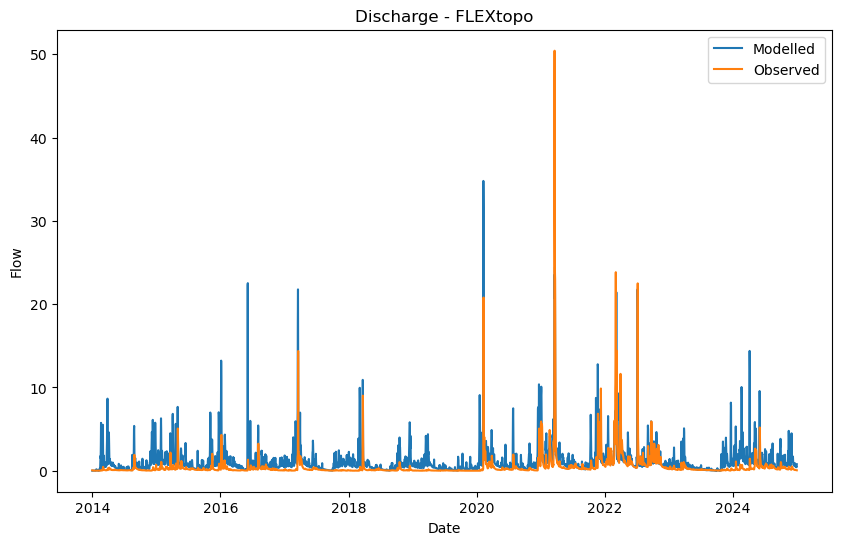

In [93]:
# Run FLEXtopo with the merged forcing dataframe

Qm = FLEXtopo(ParPlateau, ParHillslope, ParWetland, ParCatchment, forcing, landscape_per)
Qo = forcing["Qo"]

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(forcing.index, Qm, label='Modelled')
ax.plot(forcing.index, Qo, label='Observed')


ax.legend()
ax.set_title('Discharge - FLEXtopo')
ax.set_xlabel('Date')
ax.set_ylabel('Flow')
